This file is no longer focus on how to use pandas to plot each type of graph. Instead, this file discusses about <u>subplot, text-and-arrow annotation, and other interesting graphs</u> together with the practice at the end.

In [1]:
import sys
import pandas as pd
import numpy as np
import IPython
from IPython.display import display

import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt

# https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
#plt.style.use('seaborn-v0_8')   # The 'seaborn' style is deprecated

print( f"Python {sys.version}" )
print( f"Pandas {pd.__version__}" )
print( f"NumPy {np.__version__}" )
print( f"IPython {IPython.__version__}" )
print( f"Matplotlib {mpl.__version__}" )

Python 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
Pandas 2.2.3
NumPy 2.1.3
IPython 7.34.0
Matplotlib 3.10.0


# Dataset preparation

In [2]:
# Air-Quality Dataset from https://github.com/pandas-dev/pandas/blob/main/doc/data/air_quality_no2.csv

# Load
df_air = pd.read_csv('air_quality_no2.csv')

# Convert dtype of the first column from object to datetime
df_air['datetime'] = pd.to_datetime( df_air['datetime'] )

# Preview
df_air.info()
display(df_air.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         1035 non-null   datetime64[ns]
 1   station_antwerp  95 non-null     float64       
 2   station_paris    1004 non-null   float64       
 3   station_london   969 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 32.5 KB


,datetime,station_antwerp,station_paris,station_london
0,2019-05-07 02:00:00,NaN,NaN,23.0
1,2019-05-07 03:00:00,50.5,25.0,19.0
2,2019-05-07 04:00:00,45.0,27.7,19.0
3,2019-05-07 05:00:00,NaN,50.4,16.0
4,2019-05-07 06:00:00,NaN,61.9,NaN


# 1. Subplot

## 1.1 Pandas's `.plot()`

In pandas's `.plot()`, there is a `subplots` parameter that allows us to group columns in the given dataframe into subplots.
- If `subplots=False` (default), no subplot will be used.
- If `subplots=True`, a separate subplot will be created for each column of the dataframe.
- <font color=green>(Since pandas 1.5.0)</font> If `subplots` is a sequence of column labels, a subplot will be created for each group of columns.
  - For example, `subplots=[('a', 'c'), ('b', 'd')]` will create 2 subplots: one with columns 'a' and 'c', and one with columns 'b' and 'd'. Remaining columns that aren’t specified (if any) will be plotted in additional subplots (one per column).

<Axes: >

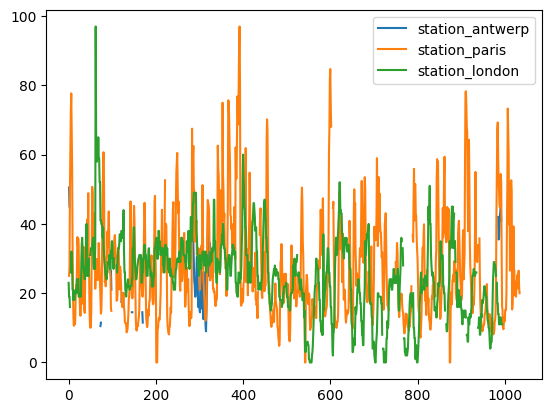

In [3]:
# Use no subplot
df_air.iloc[:,1:].plot( kind='line', subplots=False )  # default:subplots=False

array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

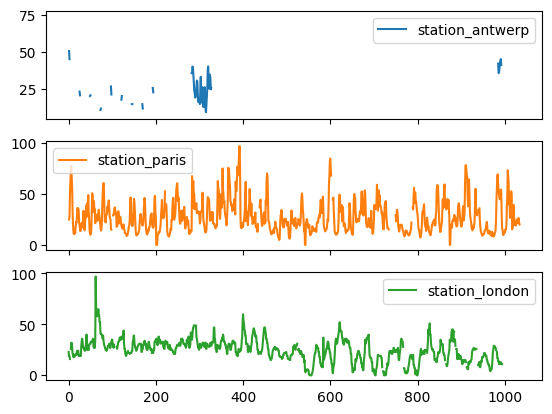

In [4]:
# Plot one column per one subplot
df_air.iloc[:,1:].plot( kind='line', subplots=True )

array([<Axes: >, <Axes: >], dtype=object)

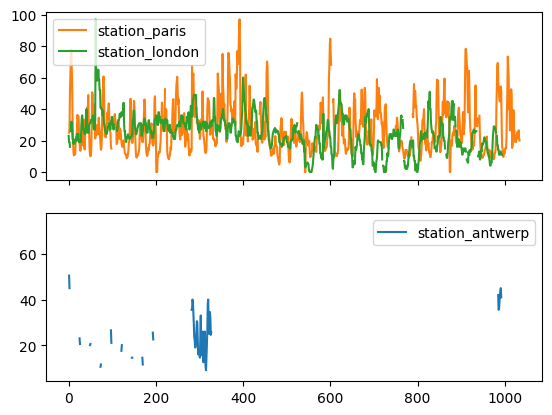

In [5]:
# Plot two subplots for two groups of columns
# This feature requires at least pandas 1.5.0
df_air.iloc[:,1:].plot.line( subplots=[('station_paris','station_london')], )

However, there are situations where you may want to use matplotlib for your subplots. For example,
- In the same figure, you want subplots of different graph types.
- You want to adjust parameters regarding the subplots created by pandas.
- You want something like GridSpec that cannot be set via pandas's `.plot()`.

In these situations, use matplotlib to first create the desired layout/style of subplots. Then, plot into each subplot using pandas's `.plot()`; don't forget to specify the right subplot axis via the `ax` parameter.

## 1.2 Matplotlib's pyplot

### 1.2.1 `plt.subplot()`: The manual method

- Use `plt.subplot(n_rows, n_cols, index)` to add a single subplot to the current figure at a specific position (`index`).
- In this command, `index` <u>must start from 1</u>.

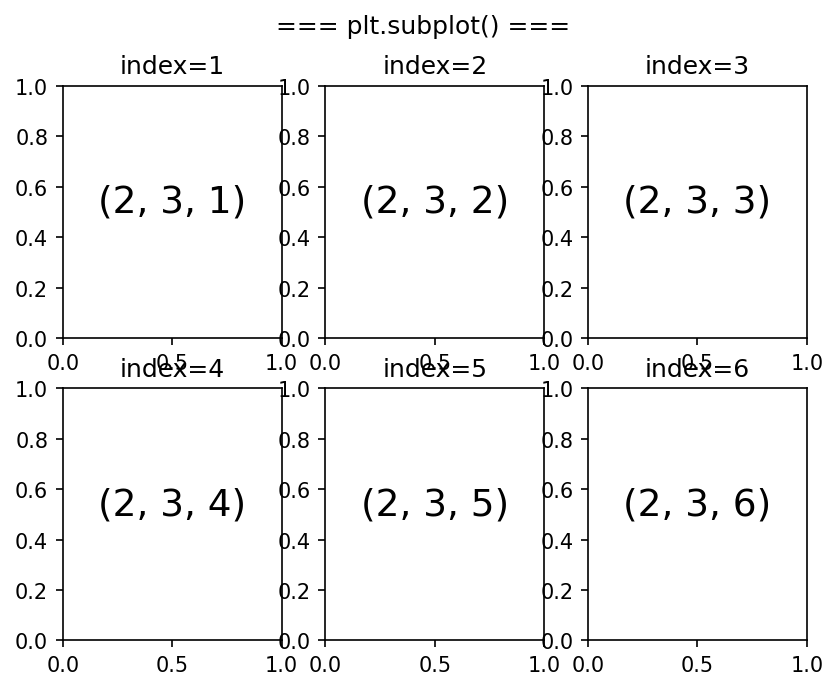

In [6]:
# (Optional) Figure setting
plt.figure(dpi=150)
plt.suptitle('=== plt.subplot() ===')  # Set the title of the figure

'''
Add each subplot to the current figure
|---|---|---|
| 1 | 2 | 3 |
 --- --- ---
| 4 | 5 | 6 |
 --- --- ---
'''
for i in range(1,7):  # There are 6 subplots, indexing as 1, 2, 3, 4, 5, 6
  # Add a new subplot axis to the current figure
  plt.subplot(2,3,i)    # 2 rows, 3 columns, the current subplot is the one with index=i

  # (Optional) Set the title of this subplot
  plt.title(f"index={i}")   # Title of the current subplot

  # Plot
  plt.text(0.5, 0.5, str((2,3,i)), fontsize=18, ha='center')  # Simply draw text to the plot area

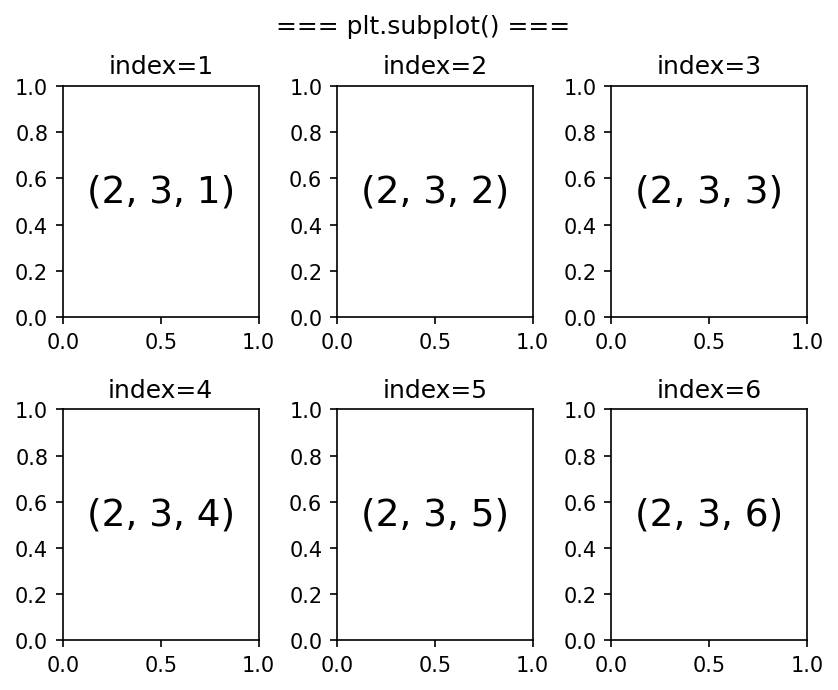

In [7]:
# Same as above but with adjusted spacing

# (Optional) Figure setting
plt.figure(dpi=150)
plt.suptitle('=== plt.subplot() ===')   # Set the title of the figure

# Adjust spacing of the subplot
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# Add each subplot to the current figure
for i in range(1,7):  # There are 6 subplots, indexing as 1, 2, 3, 4, 5, 6
  # Add a new subplot axis to the current figure
  plt.subplot(2,3,i)    # 2 rows, 3 columns, the current subplot is the one with index=i

  # (Optional) Set the title of this subplot
  plt.title(f"index={i}")   # Title of the current subplot

  # Plot
  plt.text(0.5, 0.5, str((2,3,i)), fontsize=18, ha='center')  # Simply draw text to the plot area

### 1.2.2 `plt.subplots()`: The convenient grid

- Instead of creating one axis per one subplot by repeatedly calling `plt.subplot()`, `plt.subplots()` <u>creates all axes for all subplots in one go</u> and returns the Figure and all Axes objects back.
- More consistent with Python's <u>0-based indexing</u>

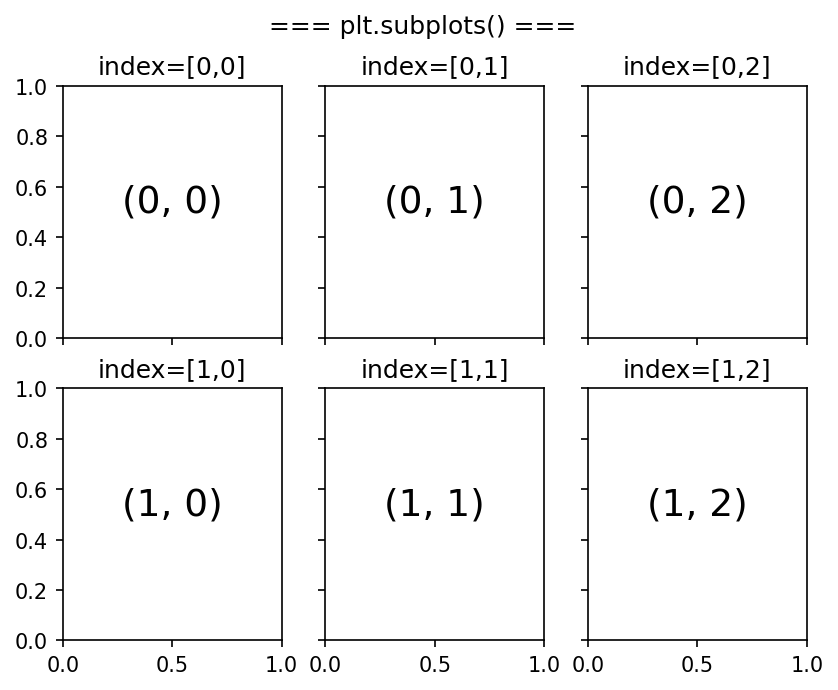

In [8]:
nrows, ncols = 2, 3

# Create axes for all subplots in one go
fig, ax = plt.subplots(nrows, ncols,
                       sharex='col', # Sharing properties among x axes: {'none', 'all', 'row', 'col'}
                                     # 'col' means each subplot column will share an x-axis
                       sharey='row', # Sharing properties among y axes: {'none', 'all', 'row', 'col'}
                                     # 'row' means each subplot row will share a y-axis.
                )

# (Optional) Figure setting
fig.dpi = 150
fig.suptitle('=== plt.subplots() ===')  # Title of the figure

# Loop to plot and style each subplot
for i in range(nrows):   # Iterate on each row (0-based indexing)
  for j in range(ncols): # Iterate on each column (0-based indexing)
    # (Optional) Set title of a particular subplot
    ax[i,j].set_title(f"index=[{i},{j}]")

    # Plot
    ax[i,j].text( 0.5, 0.5, str((i,j)), fontsize=18, ha='center' )

### 1.2.3 `plt.GridSpec()`: The flexible layout

- Define a master grid layout and then <u>tell subplots to span across multiple cells</u>
- Useful for <u>complex, non-uniform layouts</u> where subplots have different sizes or span multiple rows/columns

Text(0.5, 1.0, 'grid[1, 2]')

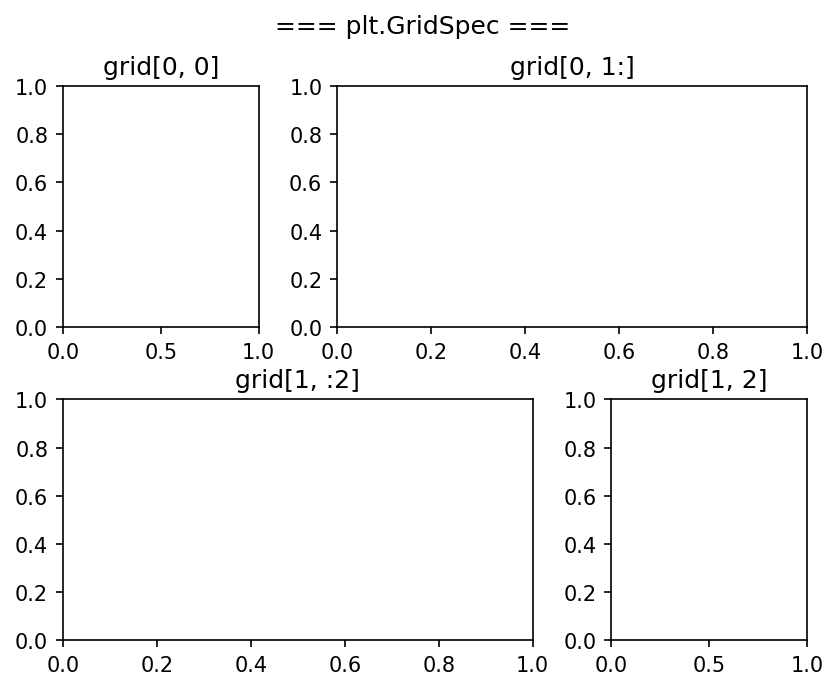

In [9]:
# (Optional) Figure setting
plt.figure(dpi=150)
plt.suptitle('=== plt.GridSpec ===')

'''
GridSpec is an interface that is recognized by plt.subplot()
    0   1   2
  |---|---|---|
0 |   |   |   |
   --- --- ---
1 |   |   |   |
   --- --- ---
'''
grid = plt.GridSpec(2, 3, wspace=0.4, hspace=0.3) # Create a grid of 2 rows and 3 columns

# Add axes to the current figure
### Subplot1
plt.subplot( grid[0, 0] )   # Add the new axis to the grid
plt.title('grid[0, 0]')     # (Optional) Set a title to this subplot
### Subplot2
plt.subplot( grid[0, 1:] )
plt.title('grid[0, 1:]')
### Subplot3
plt.subplot( grid[1, :2] )
plt.title('grid[1, :2]')
### Subplot4
plt.subplot( grid[1, 2] )
plt.title('grid[1, 2]')

Text(0.5, 1.0, 'grid[1, 2]')

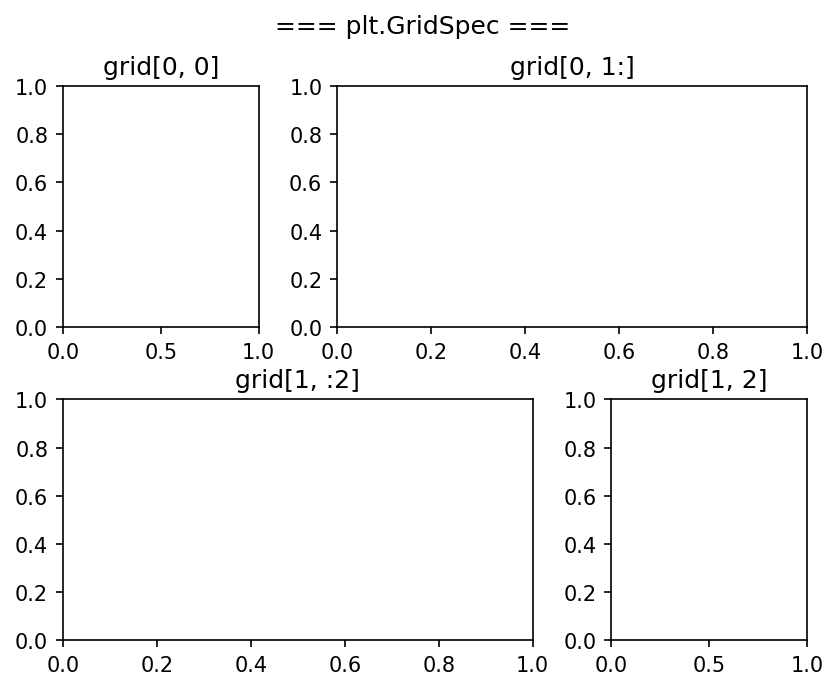

In [10]:
# Same as above but using plt.subplot2grid() to combine the grid construction and the subplot addition

# (Optional) Figure setting
plt.figure(dpi=150)
plt.suptitle('=== plt.GridSpec ===')
plt.subplots_adjust(hspace=0.3, wspace=0.4)

'''
    0   1   2
  |---|---|---|
0 |   |   |   |
   --- --- ---
1 |   |   |   |
   --- --- ---
'''
# Create a subplot at a specific location inside a regular grid
grid_shape = (2,3)
### Subplot1
plt.subplot2grid(shape=grid_shape,  # Number of rows and of columns of the grid
                 loc=(0, 0),        # Row number and column number of the axis location within the grid
                 rowspan=1,         # default=1: Number of rows for the axis to span downwards
                 colspan=1,         # default=1: Number of columns for the axis to span to the right
              )
plt.title('grid[0, 0]')     # (Optional) Set a title to this subplot
### Subplot2
plt.subplot2grid(shape=grid_shape, loc=(0,1), colspan=2)
plt.title('grid[0, 1:]')
### Subplot3
plt.subplot2grid(shape=grid_shape, loc=(1,0), colspan=2 )
plt.title('grid[1, :2]')
### Subplot4
plt.subplot2grid(shape=grid_shape, loc=(1,2))
plt.title('grid[1, 2]')

An example of using `plt.GridSpec()` for plotting a multi-axes histogram:

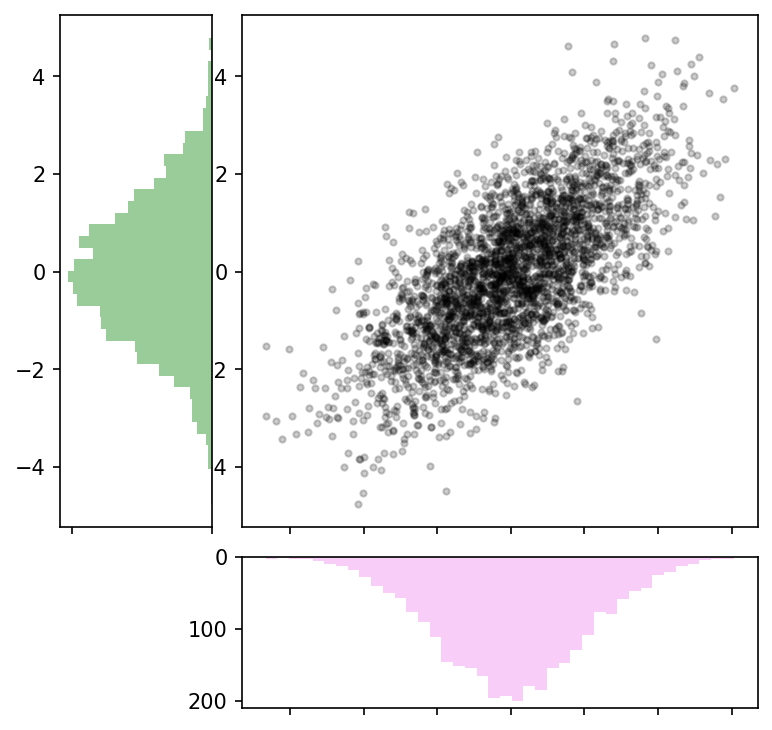

In [11]:
# Prepare data
mean = [0,0]
cov = [[1,1], [1,2]]
x, y = np.random.multivariate_normal(mean, cov, 3000).T

# (Optional) Figure setting
fig = plt.figure(figsize=(6,6), dpi=150)

# Set up the axes with GridSpec
'''
    0   1   2   3
   --- --- --- ---
0 | Y | M | M | M |
   --- --- --- ---
1 | Y | M | M | M |
   --- --- --- ---
2 | Y | M | M | M |
   --- --- --- ---
3 |   | X | X | X |
   --- --- --- ---
'''
grid = plt.GridSpec(4, 4, hspace=0.2, wspace=0.2)
ax_main = fig.add_subplot( grid[:-1, 1:] )
ax_xhist = fig.add_subplot( grid[-1, 1:], xticklabels=[], sharex=ax_main)
ax_yhist = fig.add_subplot( grid[:-1, 0], xticklabels=[], sharey=ax_main)

# Main plot: Draw a big scatter plot
ax_main.plot(x, y, 'ok', markersize=3, alpha=0.2)

# Bottom plot: attached plot (ax_xhist)
_ = ax_xhist.hist( x, bins=40,
                   histtype='stepfilled', color='violet', alpha=0.4,  # Histogram's style
                   orientation='vertical' )   # Histogram's orientation (default:'vertical')
ax_xhist.invert_yaxis()  # Flip the graph from _/\_ to \/

# Left plot: attached plot (ax_yhist)
_ = ax_yhist.hist( y, bins=40,
                   histtype='stepfilled', color='green', alpha=0.4,  # Histogram's style
                   orientation='horizontal' )  # Histogram's orientation (default:'vertical')
ax_yhist.invert_xaxis()  # Flip the graph from > to <

### 1.2.4 `plt.subplot_mosaic()`: The modern and readable way to handle non-uniform grids

- Define the layout using a simple, visual 'ASCII art' or matrix syntax
- Good for quickly and visually creating complex layouts, especially with named axes

===== ax =====
type(ax)=<class 'dict'>
ax={'A': <Axes: label='A'>, 'B': <Axes: label='B'>, 'C': <Axes: label='C'>, 'D': <Axes: label='D'>}



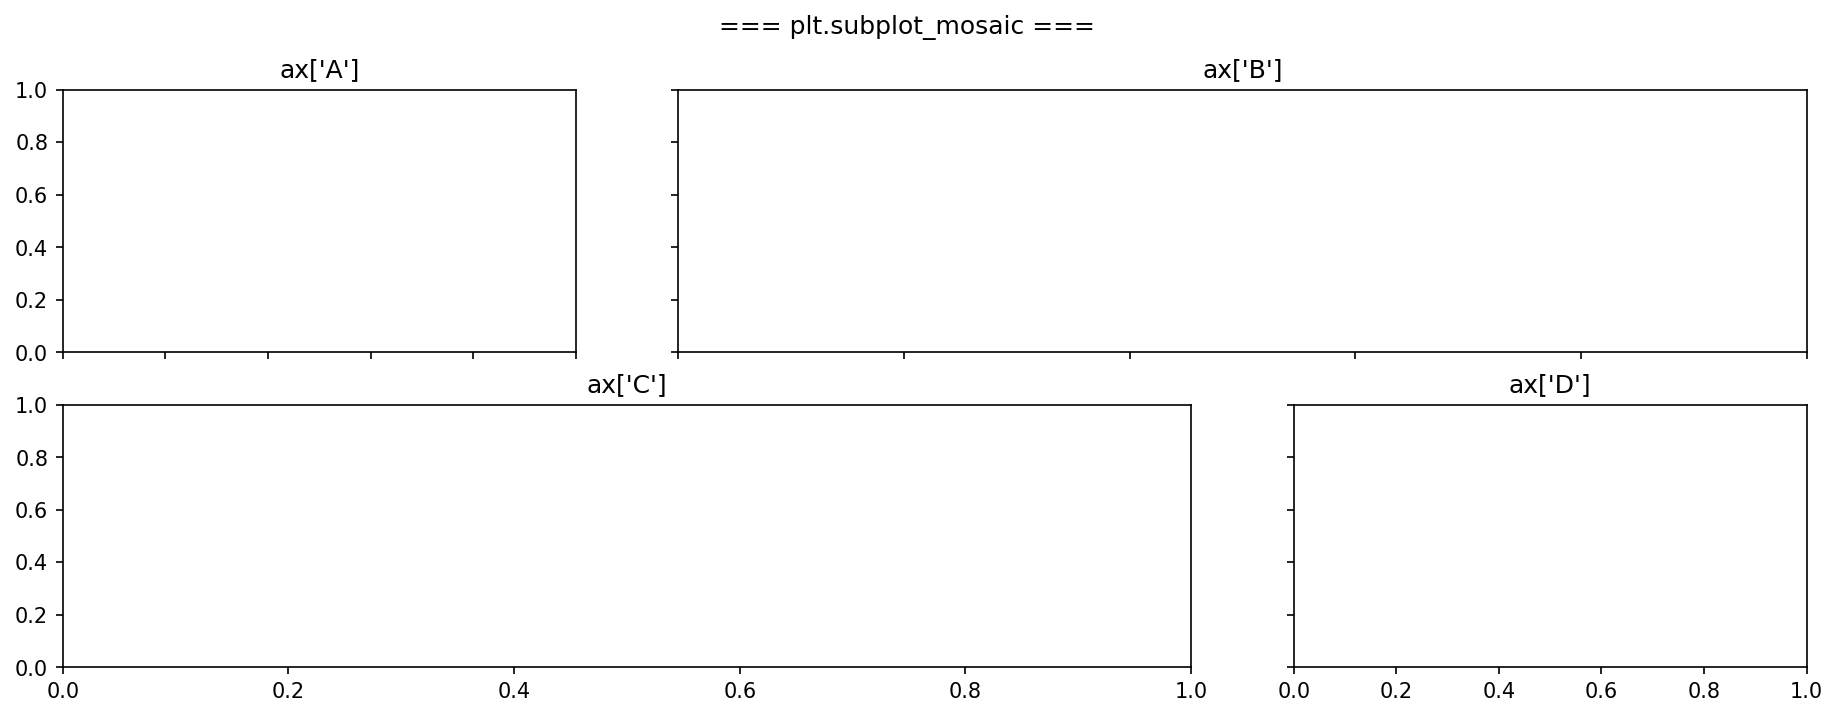

In [12]:
'''
Define the layout (the visual ASCII art) using a list of lists of strings.
Each letter represents a named subplot.
Identical letters mean the subplot spans multiple cells.
    +---+-------+
    | A |   B   |
    +---+-------+
    |   C   | D |
    +-------+---+
'''
mosaic = [['A', 'B', 'B'],
          ['C', 'C', 'D']]

# Create the figure and subplots in one function call
# This returns the figure and a dictionary of the axes
fig, ax = plt.subplot_mosaic( mosaic, sharex=True, sharey=True,
                              figsize=(15, 5)    # Set the width and height of the figure in inches
                            )

# (Optional) Figure setting
# The subplot_mosaic() creates a new figure, so figure setting must be done afterward
fig.set_dpi(150)
fig.suptitle('=== plt.subplot_mosaic ===')
fig.subplots_adjust(wspace=0.2, hspace=0.2)

# Observe the returned 'ax'
print("===== ax =====")
print(f"{type(ax)=}")
print(f"{ax=}\n")

# Access each subplot by its name in the dictionary
ax['A'].set_title("ax['A']")
ax['B'].set_title("ax['B']")
ax['C'].set_title("ax['C']")
ax['D'].set_title("ax['D']")

# Display the final plot
plt.show()

What if we create a non-rectangular or non-continuous mosaic?


In [14]:
mosaic = [['A', 'A', 'A'],
          ['B', 'A', 'B']]

# Create the figure and subplots in one function call
# This returns the figure and a dictionary of the axes
fig, ax = plt.subplot_mosaic( mosaic, sharex=True, sharey=True )   # ValueError

ValueError: While trying to layout
array([['A', 'A', 'A'],
       ['B', 'A', 'B']], dtype=object)
we found that the label 'A' specifies a non-rectangular or non-contiguous area.

<Figure size 640x480 with 0 Axes>

# 2. Text, label, and annotation

Gallery of examples in https://matplotlib.org/stable/gallery/text_labels_and_annotations/index.html

**EX1:** The first example of text and arrow annotation using matplotlib's pyplot (without using pandas.DataFrame yet)

In [21]:
# Prepare data
x = np.linspace(0, 20, 1000)

# Preview
print(f"type:{type(x)} , shape:{x.shape} , dtype:{x.dtype} , min:{np.min(x)} , max:{np.max(x)}")

type:<class 'numpy.ndarray'> , shape:(1000,) , dtype:float64 , min:0.0 , max:20.0


Text(2, -6, 'local minimum')

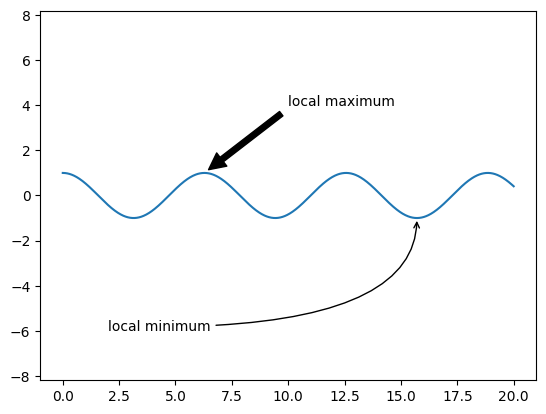

In [22]:
# Plot with annotation

# (Optional) Axis setting
ax = plt.gca()   # Get current axes
ax.axis('equal') # Set equal scaling (i.e., make circles circular) by changing axis limits

# Plot
plt.plot(x, np.cos(x))

# Add annotation
plt.annotate('local maximum', xy=(6.28,1), xytext=(10,4),
             arrowprops=dict(facecolor='black', shrink=0.05) )
plt.annotate('local minimum', xy=(5 * np.pi, -1), xytext=(2,-6),
             arrowprops=dict(arrowstyle="->",
                             connectionstyle="angle3,angleA=0,angleB=-90") )

**EX2:** Effect of holidays on US births (annotate the plot drawn by pandas's .plot())

While the plot can be drawn by pandas's `.plot()`, the annotation is done by matplotlib's pyplot.

> The codes in this example are from the book entitled "Python Data Science Handbook: Essential tools for working with data" by Jake VanderPlas.

- Load data

In [23]:
# Load data
df = pd.read_csv('births.csv')

# Preview data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15547 entries, 0 to 15546
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    15547 non-null  int64  
 1   month   15547 non-null  int64  
 2   day     15067 non-null  float64
 3   gender  15547 non-null  object 
 4   births  15547 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 607.4+ KB


,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


- Remove all outliers using a robust sigma-clipping operation

In [24]:
# Get the values at percentile 25%, 50%, and 75%
quartiles = np.percentile( df['births'], [25, 50, 75] )
print('quartiles', quartiles)

quartiles [4358.  4814.  5289.5]


In [25]:
# Get the median value
mu = quartiles[1]    # Percentile 50%

# A robust estimate of the sample mean, where 0.74 comes from the interquartile range of a Guassian distribution
sig = 0.74 * (quartiles[2] - quartiles[0])
print(f"mu={mu} , sig={sig}")

mu=4814.0 , sig=689.31


In [26]:
# Remove outliers
df = df.query("(births > @mu - 5 * @sig) & (births < @mu + 5 * @sig)")
df.loc[: , 'day'] = df.loc[ : , 'day'].astype(int)

# Preview data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 14610 entries, 0 to 15066
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    14610 non-null  int64  
 1   month   14610 non-null  int64  
 2   day     14610 non-null  float64
 3   gender  14610 non-null  object 
 4   births  14610 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 684.8+ KB


,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


- Prepare data for plotting

In [27]:
# Uncomment codes in this cell if you want to display the total number of newborns in each calendar date despite of sex
# HOWEVER, running this cell will affect the annotation shown in the last cell of this section (= text and arrow annotation not appear)

# Despite of sex, find the total number of newborns for each day
#df = df.groupby(by=['year','month','day'])['births'].sum().reset_index()
#df

In [28]:
# Use datetime as row labels
# For 15FEB2012, it will become (2012 * 10000) + (2 * 100) + 15 = 20120215
df.index = pd.to_datetime( (10000 * df.year) + (100 * df.month) + df.day,
                           format='%Y%m%d')

# Preview
print(df.index)
df

DatetimeIndex(['1969-01-01', '1969-01-01', '1969-01-02', '1969-01-02',
               '1969-01-03', '1969-01-03', '1969-01-04', '1969-01-04',
               '1969-01-05', '1969-01-05',
               ...
               '1988-12-27', '1988-12-27', '1988-12-28', '1988-12-28',
               '1988-12-29', '1988-12-29', '1988-12-30', '1988-12-30',
               '1988-12-31', '1988-12-31'],
              dtype='datetime64[ns]', length=14610, freq=None)


,year,month,day,gender,births
1969-01-01,1969,1,1.0,F,4046
1969-01-01,1969,1,1.0,M,4440
1969-01-02,1969,1,2.0,F,4454
1969-01-02,1969,1,2.0,M,4548
1969-01-03,1969,1,3.0,F,4548
...,...,...,...,...,...
1988-12-29,1988,12,29.0,M,5944
1988-12-30,1988,12,30.0,F,5742
1988-12-30,1988,12,30.0,M,6095
1988-12-31,1988,12,31.0,F,4435


In [29]:
# Find the average births over the course of the calendar year
df_by_date = df.pivot_table( index=[df.index.month, df.index.day],
                             columns=None,
                             values='births',
                             aggfunc='mean')

# Preview
df_by_date

births
1  1   4009.225
   2   4247.400
   3   4500.900
   4   4571.350
   5   4603.625
...         ...
12 27  4850.150
   28  5044.200
   29  5120.150
   30  5172.350
   31  4859.200

[366 rows x 1 columns]

In [30]:
# Convert the row labels from MultiIndex to datetime index
from datetime import datetime
df_by_date.index = [ datetime(2012, month, day) for (month,day) in df_by_date.index]

# Preview
print(df_by_date.index)
df_by_date.head()

DatetimeIndex(['2012-01-01', '2012-01-02', '2012-01-03', '2012-01-04',
               '2012-01-05', '2012-01-06', '2012-01-07', '2012-01-08',
               '2012-01-09', '2012-01-10',
               ...
               '2012-12-22', '2012-12-23', '2012-12-24', '2012-12-25',
               '2012-12-26', '2012-12-27', '2012-12-28', '2012-12-29',
               '2012-12-30', '2012-12-31'],
              dtype='datetime64[ns]', length=366, freq=None)


,births
2012-01-01,4009.225
2012-01-02,4247.400
2012-01-03,4500.900
2012-01-04,4571.350
2012-01-05,4603.625


- Plot a line graph without annotation

Text(0, 0.5, 'The average number of births')

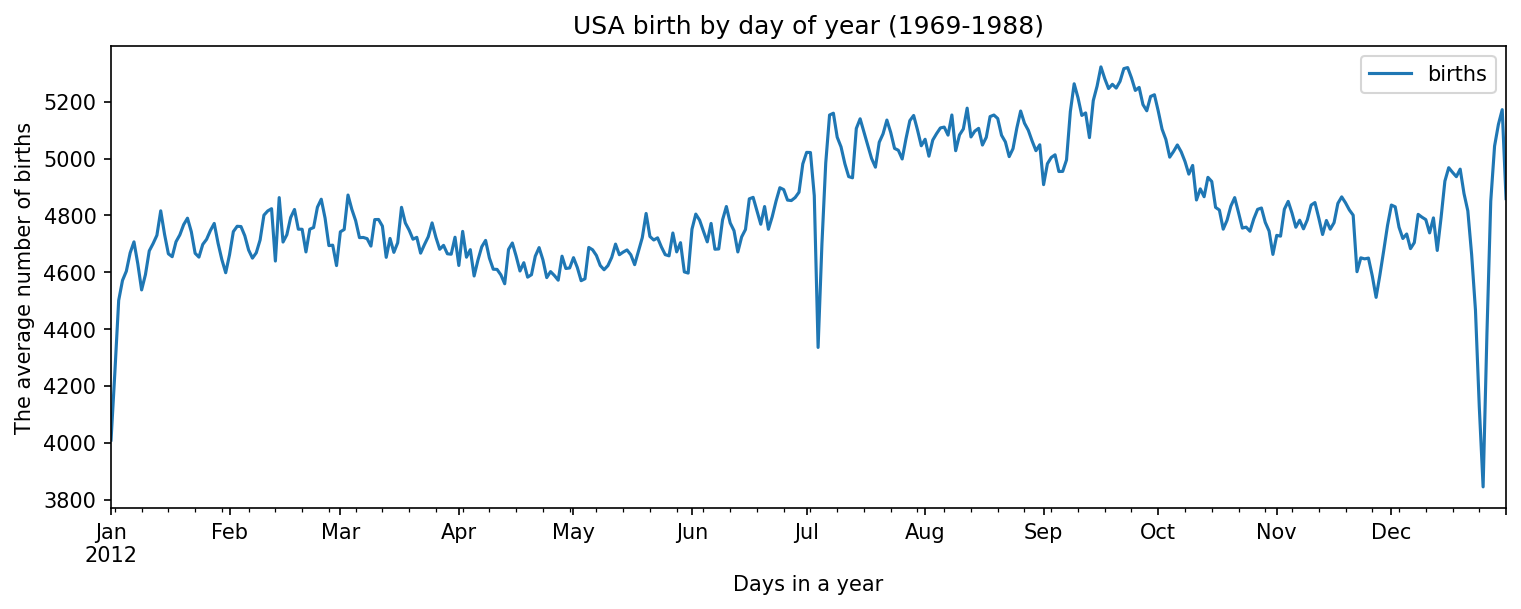

In [31]:
# (Optional) Figure setting
fig, ax = plt.subplots(figsize=(12,4),dpi=150)

# Plot
df_by_date.plot(ax=ax)

# (Optional) Set the graph title
ax.set_title('USA birth by day of year (1969-1988)')

# (Optional) Set labels in both axes
ax.set_xlabel('Days in a year')
ax.set_ylabel('The average number of births')

- Plot a line graph with text and arrow annotation

Text(-30, 0, 'Christmas')

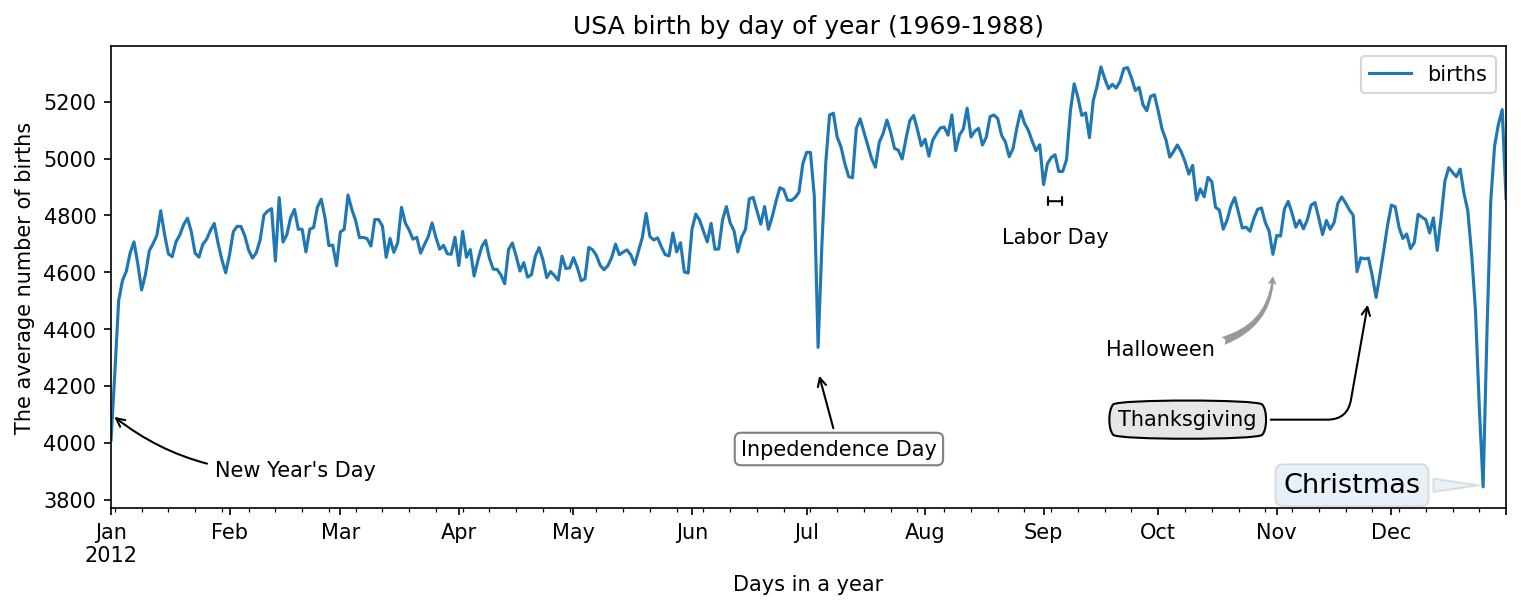

In [32]:
# (Optional) Figure setting
fig, ax = plt.subplots(figsize=(12,4),dpi=150)

# Plot
df_by_date.plot(ax=ax)

# (Optional) Set the graph title
ax.set_title('USA birth by day of year (1969-1988)')

# (Optional) Set labels in both axes
ax.set_xlabel('Days in a year')
ax.set_ylabel('The average number of births')

# Text + arrow
ax.annotate("New Year's Day",
             xy=('2012-1-1', 4100), xycoords='data',
             xytext=(50,-30), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.2'))

# Text + arrow + bounding box
ax.annotate("Inpedendence Day",
             xy=('2012-7-4', 4250), xycoords='data',
             bbox=dict(boxstyle='round', fc='none', ec='gray'),
             xytext=(10,-40), textcoords='offset points', ha='center',
             arrowprops=dict(arrowstyle='->'))

# Text + time-spanning bar
ax.annotate("Labor Day",
             xy=('2012-9-4', 4850), xycoords='data', ha='center',
             xytext=(0,-20), textcoords='offset points')
ax.annotate('',
             xy=('2012-9-1', 4850), xytext=('2012-9-7', 4850),
             xycoords='data', textcoords='data',
             arrowprops={'arrowstyle':'|-|,widthA=0.2,widthB=0.2'} )

# Text + fancy arrow
ax.annotate('Halloween',
             xy=('2012-10-31', 4600), xycoords='data',
             xytext=(-80,-40), textcoords='offset points',
             arrowprops=dict( arrowstyle='fancy',
                              fc='0.6', ec='none',
                              connectionstyle='angle3,angleA=0,angleB=-90') )

# Text + arrow + round box
ax.annotate('Thanksgiving',
            xy=('2012-11-25',4500), xycoords='data',
            xytext=(-120,-60), textcoords='offset points',
            bbox=dict(boxstyle='round4,pad=.5', fc='0.9'),
            arrowprops=dict( arrowstyle='->',
                             connectionstyle='angle,angleA=0,angleB=80,rad=20') )

# Text + fancy arrow + round box
ax.annotate('Christmas',
            xy=('2012-12-25',3850), xycoords='data',
            xytext=(-30,0), textcoords='offset points',
            size=13, ha='right', va='center',
            bbox=dict(boxstyle='round', alpha=0.1),
            arrowprops=dict( arrowstyle='wedge,tail_width=0.5',
                             alpha=0.1) )

# 3. Other plots

## 3.1 Radar chart (a.k.a., Spider chart, Polar chart)

- Be careful when using this chart, although it looks cool, this chart is often criticized by dataviz specialists. (Ref: https://www.data-to-viz.com/caveat/spider.html)
  - **Circular layout = harder to read:** It is easier (and more accurate) to compare values in the bar plot.
  - **Not support ranking:** Ranking is more difficult in radar charts as there are no starts and ends.
  - **Category order hugely affects the shape:** Radar chart readers will probably focus on the shape observed. This can be misleading since this shape highly depends on the ordering of categories around the plot.
  - **Over-evaluation of differences:** The area of a shape in a radar chart also increases quadratically rather than linearly, which could lead viewers to think that small changes are more significant than they actually are.

- Many suggest to replace spider charts with bar or lollipop charts.

[Text(0.0, 0, 'A'),
 Text(1.2566370614359172, 0, 'B'),
 Text(2.5132741228718345, 0, 'C'),
 Text(3.7699111843077517, 0, 'D'),
 Text(5.026548245743669, 0, 'E')]

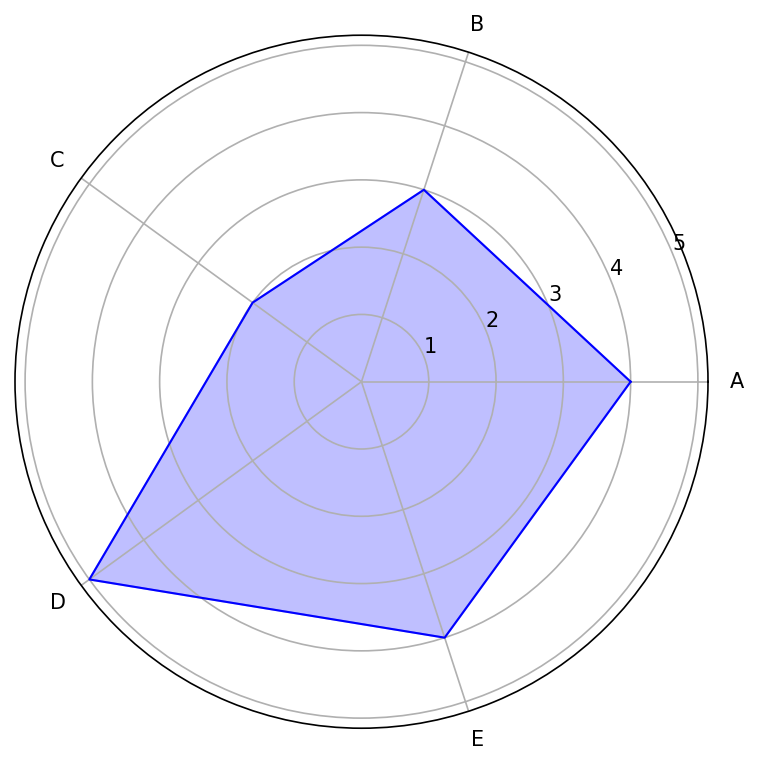

In [33]:
# Spider chart is actually a line chart with polar coordinate

# Create dummy data
labels = ['A', 'B', 'C', 'D', 'E']
values = [4, 3, 2, 5, 4]
values += values[:1]    # Add the end point to close the loop

# Create a list of angles
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

# Specify the polar projection to create a radar chart
# Typically done using subplot() or subplots() with polar=True
# Note that the polar coordinate system is not available in the standard 2D plotting functions
fig, ax = plt.subplots(figsize=(6,6), dpi=150, subplot_kw=dict(polar=True))
ax.fill(angles, values, color='blue', alpha=0.25)
ax.plot(angles, values, color='blue', linewidth=1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

## 3.2 Lollipop chart

- A lollipop chart is a cleaner, minimalist alternative of a traditional bar chart.
- A lollipop chart is represented as circles (the "lollipops") on top of a line (the "stick").

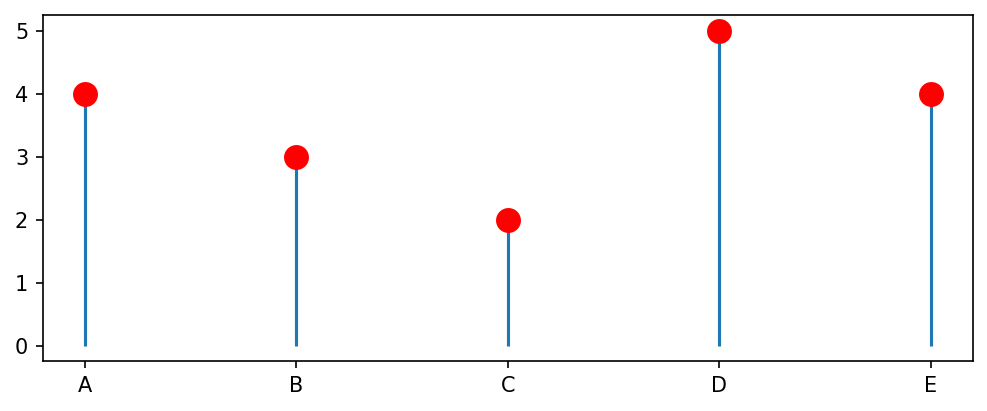

In [34]:
# (Optional) Figure setting
fig, ax = plt.subplots(figsize=(8,3),dpi=150)

# Create dummy data
labels = ['A', 'B', 'C', 'D', 'E']
values = [4, 3, 2, 5, 4]

# Create the sticks with a stem chart
# plt.stem() draws lines (stems) from a base to data points, with circles (dots) at the top representing values
ax.stem(labels, values, basefmt=" ")

# (Optional) Add red lollipops on top with a scatter chart
# 'zorder' is the drawing order of artists. Artists with higher zorder are drawn on top.
ax.scatter(labels, values, s=120, color='red', zorder=10)

## 3.3 Parallel chart (a.k.a., Parallel coordinate plot)

- A parallel chart is a way to visualize multi-dimensional data. Each feature or variable is represented by a vertical axis, and each line or path across the axes represents a single data point.
- A parallel chart is useful when we have multiple features for each item and want to compare them.

- Pandas is probably the best way to make a parallel coordinate plot as it offers a `parallel_coordinates()` function dedicated to this.

,Class,Feature1,Feature2,Feature3,Feature4
0,A,1,4,7,9
1,A,2,5,6,8
2,A,3,6,5,7
3,B,6,9,4,6
4,B,5,8,5,5
5,B,4,7,6,4
6,C,9,12,7,3
7,C,8,11,8,2
8,C,7,10,9,1


<Axes: >

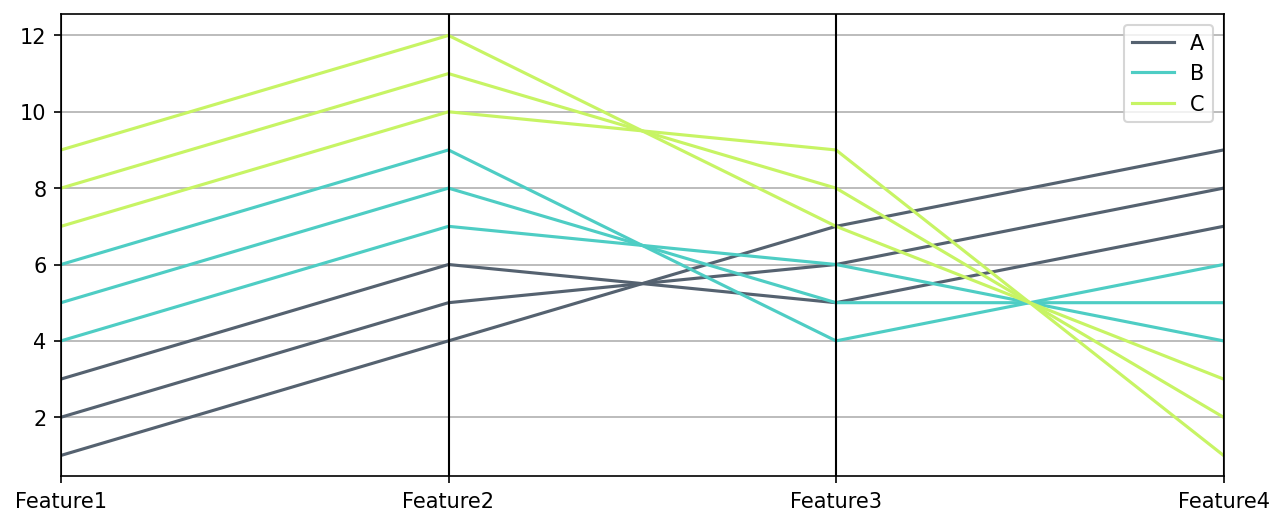

In [35]:
# (Optional) Figure setting
fig, ax = plt.subplots(figsize=(10,4),dpi=150)

# Dummy data, each with four features
df = pd.DataFrame({
    'Class': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
    'Feature1': [1, 2, 3, 6, 5, 4, 9, 8, 7],
    'Feature2': [4, 5, 6, 9, 8, 7, 12, 11, 10],
    'Feature3': [7, 6, 5, 4, 5, 6, 7, 8, 9],
    'Feature4': [9, 8, 7, 6, 5, 4, 3, 2, 1]
})
display(df)

# Create the parallel coordinates plot
pd.plotting.parallel_coordinates(df, class_column='Class',
                                 color=['#556270', '#4ECDC4', '#C7F464'],
                                 ax=ax)

## 3.4 Wilkinson dot plot

**Boxplot** → Great for summaries.
- ✅ Summarizes distribution (median, quartiles, whiskers, outliers)
- ✅ Compact, great for comparing groups
- ❌ Hides raw data (can’t see how many points at each value)
- ❌ Median line may overlap with quartiles and become invisible

**Histogram** → Great for shapes.
- ✅ Shows distribution shape clearly
- ✅ Good for large datasets
- ❌ Bar heights are abstract (harder to “see” individual data points)
- ❌ Bin width choice can change interpretation

**Wilkinson dot plot** → Great for transparency (see the raw data + frequency together).
- ✅ Shows every individual observation (each dot = 1 data point)
- ✅ Neat stacking makes frequency visible without bars
- ✅ Intuitive: “like stacking marbles into bins”
- ❌ Can be cluttered with very large datasets
- ❌ Less compact than boxplots

In [36]:
# Randomly create small numeric dataset
np.random.seed(42)  # for reproducibility
feature1 = np.random.randint(1, 10, size=20)  # 20 numbers between 1 and 9
feature2 = np.random.randint(1, 10, size=20)  # 20 numbers between 1 and 9
feature3 = np.random.randint(1, 10, size=20)  # 20 numbers between 1 and 9

# Put into DataFrame
df = pd.DataFrame({'feature1':feature1, 'feature2':feature2, 'feature3':feature3})
df

,feature1,feature2,feature3
0,7,1,5
1,4,6,2
2,8,9,4
3,5,1,7
4,7,3,8
5,3,7,3
6,7,4,1
7,8,9,4
8,5,3,2
9,4,5,8


,count
feature1,
2,2
3,2
4,2
5,4
6,2
7,3
8,5


,count
feature2,
1,2
2,2
3,3
4,2
5,2
6,1
7,3
9,5


,count
feature3,
1,1
2,5
3,1
4,5
5,1
6,3
7,1
8,3


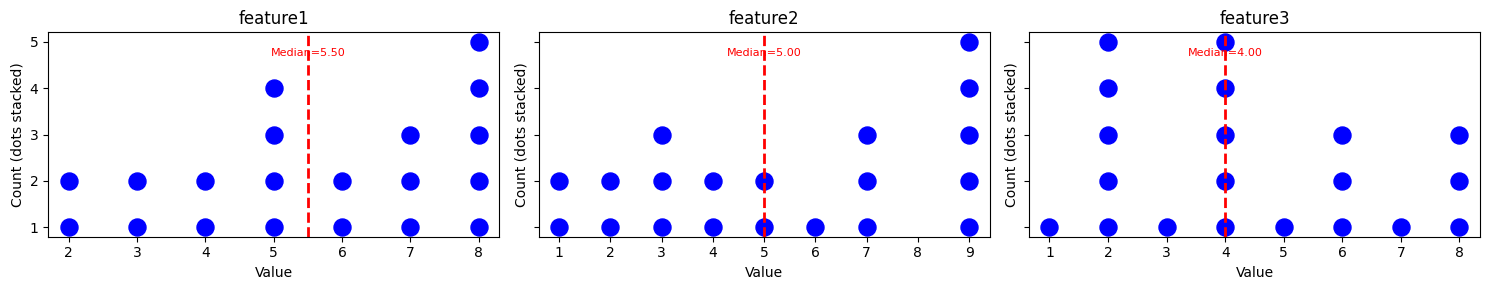

In [37]:
# Wilkinson dot plot (no direct plotting function in Matplotlib and Seaborn)
def wilkinson_dotplot(ax, series, title, dot_size=150):
    # Bin values into width=1
    bin_edges = np.arange(int(series.min()) - 1, int(series.max()) + 2, 1)
    binned = pd.cut(series, bins=bin_edges, labels=bin_edges[1:], include_lowest=True)   # Return an interval object
    x_vals = binned.astype(int)

    # Count values per bin
    counts = x_vals.value_counts().sort_index()
    display(counts)

    # Plot stacked dots
    for x, count in counts.items():
        ax.scatter([x]*count, range(1, count+1), color="blue",
                   s=dot_size)

    # Add a median line + text
    median_val = series.median()
    ax.axvline(median_val, color="red", linestyle="--", linewidth=2)
    ax.text(median_val, ax.get_ylim()[1]*0.9, f"Median={median_val:.2f}",
            color="red", ha="center", fontsize=8)

    ax.set_title(title)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count (dots stacked)")


# Create subplots for each column
fig, axes = plt.subplots(1, df.shape[-1], figsize=(15, 3), sharey=True)

for ax, col in zip(axes, df.columns):
    wilkinson_dotplot(ax, df[col], col)

plt.tight_layout()
plt.show()

# Practice

Use our old pokemon dataset to do the following data visualization.

1. (1.5 points) Plot the number of each pokemon type.

![Question1](matplotlib3_question1_answer.png)

2. (1.5 points) For pokemons whose type1 is fire, water, or bug, create one figure (with several subplots) to conclude their histograms of hp, attack, and defense.

![Question2](matplotlib3_question2_answer.png)